Trial C:
lr = 5e-5
weights = [1, 3, 8, 3]
lambda_cldice = 0.7

In [1]:
import os
import cv2
import pickle
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp
import albumentations as A

c:\Users\HP\anaconda3\envs\dl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
BASE = r"C:\Users\HP\Desktop\GAVE2_preliminary\training"

with open("dataset_split.pkl", "rb") as f:
    split = pickle.load(f)

train_files = split["train"]
val_files = split["val"]
test_files = split["test"]

print(len(train_files), len(val_files), len(test_files))

35 7 8


In [4]:
train_transform = A.Compose(
    [
        A.HorizontalFlip(p=0.5),
        A.Rotate(limit=15, p=0.5),
        A.RandomBrightnessContrast(
            brightness_limit=0.15,
            contrast_limit=0.15,
            p=0.5
        )
    ],
    additional_targets={
        "fov": "mask"
    }
)

In [5]:
def convert_av_to_mask(av):
    mask = np.zeros(av.shape[:2], dtype=np.uint8)

    red = np.all(av == [255, 0, 0], axis=-1)
    green = np.all(av == [0, 255, 0], axis=-1)
    blue = np.all(av == [0, 0, 255], axis=-1)

    mask[red] = 1
    mask[green] = 2
    mask[blue] = 3

    return mask

In [6]:
def preprocess_retina(image, fov):
    image = image * fov[:, :, None]

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    r = clahe.apply(image[:, :, 0])
    g = clahe.apply(image[:, :, 1])
    b = clahe.apply(image[:, :, 2])

    enhanced = np.stack([r, g, b], axis=-1)

    return enhanced

In [7]:
class AVDataset(Dataset):
    def __init__(self, file_list, base_path, transform=None, resize=(1152, 768)):
        self.file_list = file_list
        self.base_path = base_path
        self.transform = transform
        self.resize = resize

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        filename = self.file_list[idx]

        image_path = os.path.join(self.base_path, "images", filename)
        av_path = os.path.join(self.base_path, "av", filename)
        fov_path = os.path.join(self.base_path, "masks", filename)

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        av = cv2.imread(av_path)
        av = cv2.cvtColor(av, cv2.COLOR_BGR2RGB)

        fov = cv2.imread(fov_path, 0)
        fov = (fov > 0).astype(np.uint8)

        mask = convert_av_to_mask(av)

        if self.transform:
            augmented = self.transform(
                image=image,
                mask=mask,
                fov=fov
            )
            image = augmented["image"]
            mask = augmented["mask"]
            fov = augmented["fov"]

        image = preprocess_retina(image, fov)

        image = cv2.resize(image, self.resize)
        mask = cv2.resize(mask, self.resize, interpolation=cv2.INTER_NEAREST)

        image = image.astype(np.float32) / 255.0
        image = np.transpose(image, (2, 0, 1))

        image = torch.tensor(image, dtype=torch.float32)
        mask = torch.tensor(mask, dtype=torch.long)

        return image, mask

In [8]:
train_dataset = AVDataset(train_files, BASE, transform=train_transform)
val_dataset = AVDataset(val_files, BASE)
test_dataset = AVDataset(test_files, BASE)

In [9]:
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=2, shuffle=False)

In [10]:
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=4
).to(device)

In [11]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs,
            targets,
            weight=self.alpha,
            reduction='none'
        )

        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        return focal_loss.mean()

In [12]:
class SoftCLDiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.softmax(preds, dim=1)

        vessel_pred = preds[:, 1:, :, :].sum(dim=1)

        vessel_gt = (targets > 0).float()

        intersection = (vessel_pred * vessel_gt).sum()
        union = vessel_pred.sum() + vessel_gt.sum()

        cldice = (2 * intersection + self.smooth) / (union + self.smooth)

        return 1 - cldice

In [13]:
class CombinedLoss(nn.Module):
    def __init__(self, class_weights, lambda_cldice=1.0):
        super().__init__()

        self.ce = nn.CrossEntropyLoss(weight=class_weights)
        self.focal = FocalLoss(alpha=class_weights)
        self.cldice = SoftCLDiceLoss()

        self.lambda_cldice = lambda_cldice

    def forward(self, preds, targets):
        ce_loss = self.ce(preds, targets)
        focal_loss = self.focal(preds, targets)
        cldice_loss = self.cldice(preds, targets)

        total_loss = (
            0.3 * ce_loss +
            0.3 * focal_loss +
            self.lambda_cldice * cldice_loss
        )

        return total_loss

In [14]:
class_weights = torch.tensor([1.0, 5.0, 30.0, 5.0]).to(device)

criterion = CombinedLoss(
    class_weights=class_weights,
    lambda_cldice=0.3
)

In [15]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-5,
    weight_decay=1e-4
)

In [16]:
def calculate_metrics(preds, targets, num_classes=4):
    preds = torch.argmax(preds, dim=1)

    precisions = []
    recalls = []
    f1s = []
    ious = []

    eps = 1e-7

    for cls in range(1, num_classes):
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        TP = (pred_cls * target_cls).sum()
        FP = (pred_cls * (1 - target_cls)).sum()
        FN = ((1 - pred_cls) * target_cls).sum()

        precision = TP / (TP + FP + eps)
        recall = TP / (TP + FN + eps)
        f1 = 2 * precision * recall / (precision + recall + eps)
        iou = TP / (TP + FP + FN + eps)

        precisions.append(precision.item())
        recalls.append(recall.item())
        f1s.append(f1.item())
        ious.append(iou.item())

    return {
        "precision": np.mean(precisions),
        "recall": np.mean(recalls),
        "f1": np.mean(f1s),
        "iou": np.mean(ious)
    }

In [17]:
def compute_accuracy(preds, targets):
    preds = torch.argmax(preds, dim=1)
    return (preds == targets).float().mean().item()

In [18]:
def multiclass_dice(preds, targets, num_classes=4, smooth=1e-6):
    preds = torch.argmax(preds, dim=1)

    dice_scores = []

    for cls in range(1, num_classes):  
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()

        dice = (2 * intersection + smooth) / (union + smooth)
        dice_scores.append(dice.item())

    return np.mean(dice_scores)

In [19]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0
    total_acc = 0
    total_dice = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        acc = compute_accuracy(outputs, masks)
        dice = multiclass_dice(outputs, masks)

        total_loss += loss.item()
        total_acc += acc
        total_dice += dice

    return (
        total_loss / len(loader),
        total_acc / len(loader),
        total_dice / len(loader)
    )

In [20]:
def validate(model, loader, criterion):
    model.eval()

    total_loss = 0
    total_acc = 0
    total_dice = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            acc = compute_accuracy(outputs, masks)
            dice = multiclass_dice(outputs, masks)

            total_loss += loss.item()
            total_acc += acc
            total_dice += dice

    return (
        total_loss / len(loader),
        total_acc / len(loader),
        total_dice / len(loader)
    )

In [21]:
best_val_dice = 0
EPOCHS = 15

In [22]:
for epoch in range(EPOCHS):
    train_loss, train_acc, train_dice = train_one_epoch(
        model, train_loader, optimizer, criterion
    )

    val_loss, val_acc, val_dice = validate(
        model, val_loader, criterion
    )

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save(model.state_dict(), "best_final_model.pth")

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Train Dice: {train_dice:.4f}"
    )
    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Dice: {val_dice:.4f}"
    )
    print("-"*50)

Epoch 1/15
Train Loss: 1.1146 | Train Acc: 0.3145 | Train Dice: 0.0571
Val Loss: 0.9224 | Val Acc: 0.6998 | Val Dice: 0.0228
--------------------------------------------------
Epoch 2/15
Train Loss: 1.0261 | Train Acc: 0.4203 | Train Dice: 0.0834
Val Loss: 0.9494 | Val Acc: 0.5630 | Val Dice: 0.0702
--------------------------------------------------
Epoch 3/15
Train Loss: 0.9593 | Train Acc: 0.5210 | Train Dice: 0.1078
Val Loss: 0.9428 | Val Acc: 0.5312 | Val Dice: 0.0776
--------------------------------------------------
Epoch 4/15
Train Loss: 0.9059 | Train Acc: 0.5965 | Train Dice: 0.1312
Val Loss: 0.9230 | Val Acc: 0.6140 | Val Dice: 0.0901
--------------------------------------------------
Epoch 5/15
Train Loss: 0.8641 | Train Acc: 0.6599 | Train Dice: 0.1514
Val Loss: 0.8870 | Val Acc: 0.7921 | Val Dice: 0.1053
--------------------------------------------------
Epoch 6/15
Train Loss: 0.8228 | Train Acc: 0.7178 | Train Dice: 0.1727
Val Loss: 0.8607 | Val Acc: 0.8628 | Val Dice: 0.

In [23]:
def mask_to_rgb(mask):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)

    rgb[mask == 1] = [255, 0, 0]   # Artery = Red
    rgb[mask == 2] = [0, 255, 0]   # Overlap = Green
    rgb[mask == 3] = [0, 0, 255]   # Vein = Blue

    return rgb

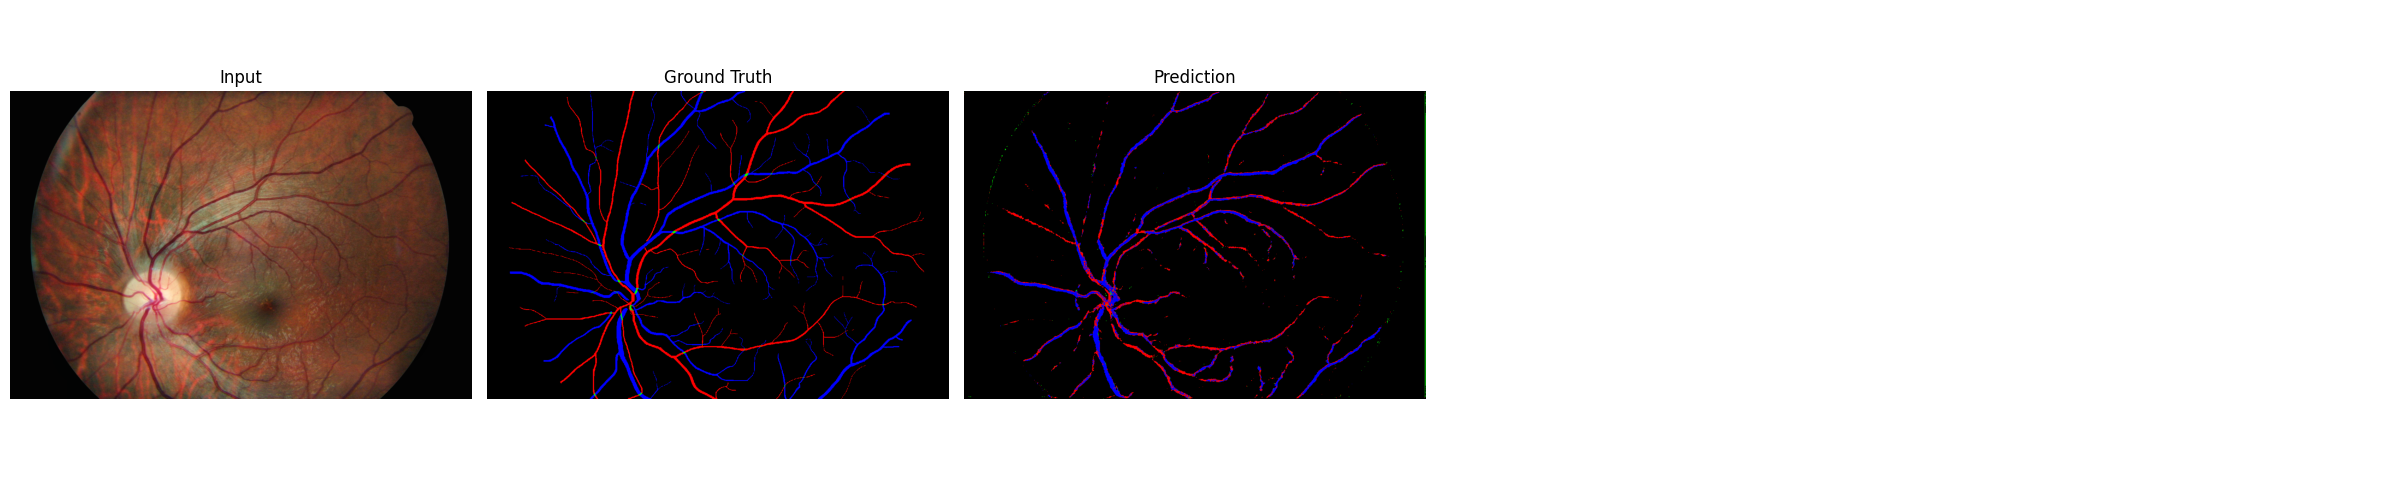

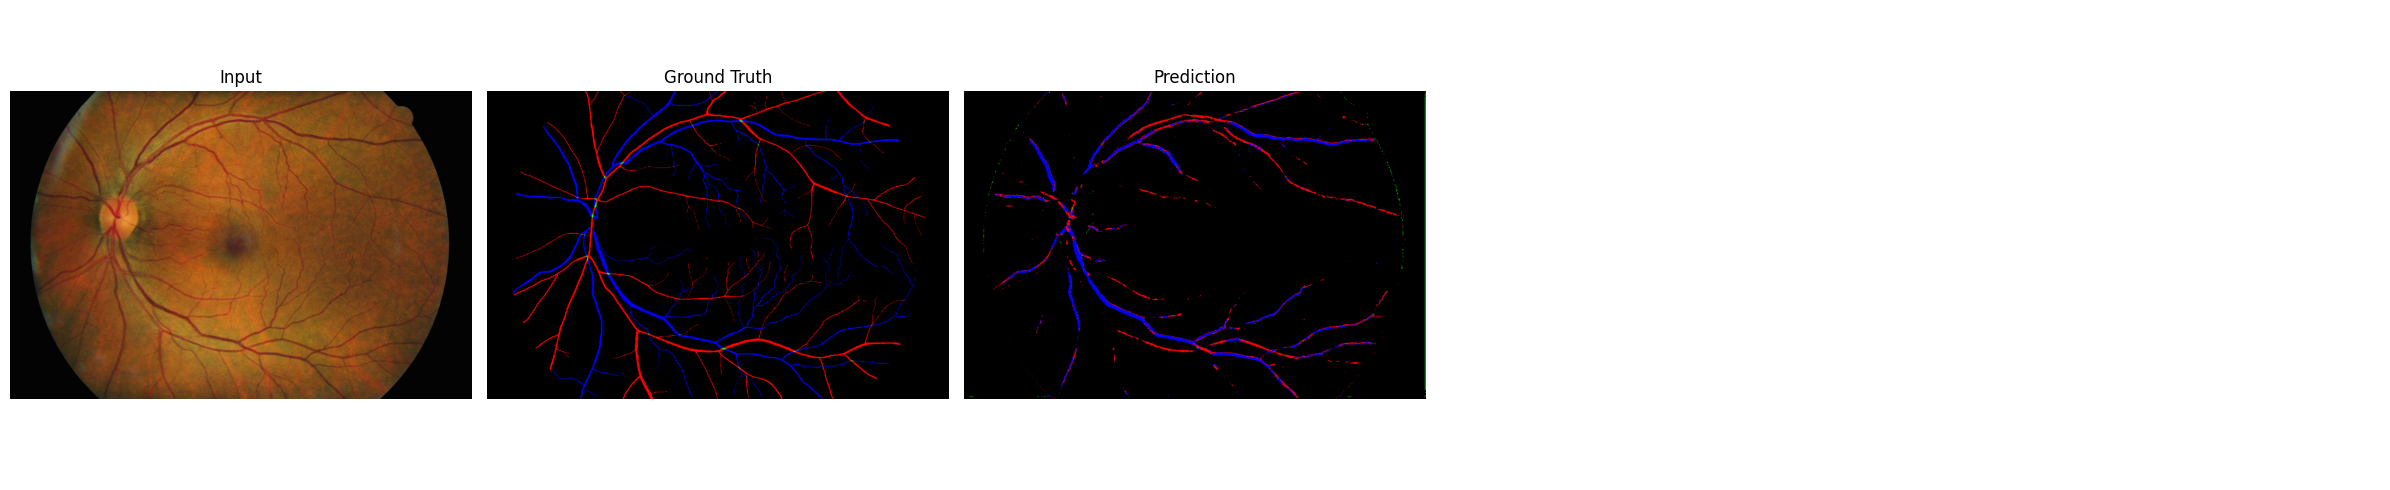

In [24]:
model.load_state_dict(torch.load("best_final_model.pth"))
model.eval()

images, masks = next(iter(test_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

images = images.cpu()
masks = masks.cpu()
preds = preds.cpu()

num_samples = min(2, len(images))

for i in range(num_samples):
    img = images[i].permute(1, 2, 0).numpy()
    gt = masks[i].numpy()
    pred = preds[i].numpy()

    gt_rgb = mask_to_rgb(gt)
    pred_rgb = mask_to_rgb(pred)


    fig, axes = plt.subplots(1, 5, figsize=(24, 5))

    axes[0].imshow(img)
    axes[0].set_title("Input")

    axes[1].imshow(gt_rgb)
    axes[1].set_title("Ground Truth")

    axes[2].imshow(pred_rgb)
    axes[2].set_title("Prediction")


    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [25]:
def compute_multiclass_metrics(model, loader, num_classes=4):
    model.eval()

    class_metrics = {}

    for cls in range(1, num_classes):
        class_metrics[cls] = {
            "tp": 0,
            "fp": 0,
            "fn": 0,
            "tn": 0
        }

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            for cls in range(1, num_classes):
                pred_cls = (preds == cls).float()
                target_cls = (masks == cls).float()

                tp = (pred_cls * target_cls).sum().item()
                fp = (pred_cls * (1 - target_cls)).sum().item()
                fn = ((1 - pred_cls) * target_cls).sum().item()
                tn = ((1 - pred_cls) * (1 - target_cls)).sum().item()

                class_metrics[cls]["tp"] += tp
                class_metrics[cls]["fp"] += fp
                class_metrics[cls]["fn"] += fn
                class_metrics[cls]["tn"] += tn

    class_names = {
        1: "Artery",
        2: "Overlap",
        3: "Vein"
    }

    print("MULTICLASS METRICS")
    print("="*60)

    for cls in range(1, num_classes):
        tp = class_metrics[cls]["tp"]
        fp = class_metrics[cls]["fp"]
        fn = class_metrics[cls]["fn"]
        tn = class_metrics[cls]["tn"]

        precision = tp / (tp + fp + 1e-6)
        recall = tp / (tp + fn + 1e-6)
        f1 = (2 * precision * recall) / (precision + recall + 1e-6)
        iou = tp / (tp + fp + fn + 1e-6)
        accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-6)

        print(f"{class_names[cls]}")
        print(f"Accuracy  : {accuracy:.4f}")
        print(f"Precision : {precision:.4f}")
        print(f"Recall    : {recall:.4f}")
        print(f"F1 Score  : {f1:.4f}")
        print(f"IoU       : {iou:.4f}")
        print("-"*60)

In [26]:
model.load_state_dict(torch.load("best_final_model.pth"))
compute_multiclass_metrics(model, test_loader)

MULTICLASS METRICS
Artery
Accuracy  : 0.9659
Precision : 0.3431
Recall    : 0.2527
F1 Score  : 0.2911
IoU       : 0.1703
------------------------------------------------------------
Overlap
Accuracy  : 0.9971
Precision : 0.0033
Recall    : 0.0098
F1 Score  : 0.0049
IoU       : 0.0025
------------------------------------------------------------
Vein
Accuracy  : 0.9739
Precision : 0.6782
Recall    : 0.4570
F1 Score  : 0.5460
IoU       : 0.3756
------------------------------------------------------------
